# Coursework 1
**Replace CID in the file name with your CID**

# Outline


- [Task 1](#task-1): Linear regression and feature selection <a name="index-task-1"></a>
  - [(1.1)](#task-11) <a name="index-task-11"></a>
  - [(1.2)](#task-12) <a name="index-task-12"></a>
  - [(1.3)](#task-13) <a name="index-task-13"></a>
  - [(1.4)](#task-14) <a name="index-task-14"></a>
- [Task 2](#task-2): Non-linear regression with Kernel Ridge Regression <a name="index-task-2"></a>
  - [(2.1)](#task-21) <a name="index-task-21"></a>
  - [(2.2)](#task-22)  <a name="index-task-22"></a>
- [Task 3](#task-3): Classification with the Multi-Layer Perceptron <a name="index-task-3"></a>
  - [(3.1)](#task-31) <a name="index-task-31"></a>
  - [(3.2)](#task-32)  <a name="index-task-32"></a>



---



<a name="task-1"></a>

# Task 1: Linear regression and feature selection [(index)](#index-task-1)

In [306]:
# import useful packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# set global config for matplotlib to make plots readable
SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [307]:
# load data
data_train = pd.read_csv("asteroid_observations_train.csv")
data_test = pd.read_csv("asteroid_observations_test.csv")

# show the shape of the data
print("train data shape: ", data_train.shape)
print("test data shape: ", data_test.shape)

data_train.head()

train data shape:  (638, 9)
test data shape:  (160, 9)


,Absolute magnitude,Albedo,Number of observations,Observation arc length,Orbital eccentricity,Orbital inclination,Orbital period,Asteroid diameter,Asteroid class
0,18.1,0.041,15,2.0,0.201590,11.975800,3.912298,1.573,MBA
1,12.5,0.139,349,7208.0,0.032746,8.793883,11.942668,12.355,TJN
2,14.1,0.062,705,25309.0,0.179314,27.433960,5.749452,8.862,OMB
3,16.9,0.097,91,3805.0,0.066114,13.813845,4.592982,2.139,MBA
4,11.5,0.062,1300,9606.0,0.008824,5.595907,12.006096,30.763,TJN


In [308]:
data_test.head()

,Absolute magnitude,Albedo,Number of observations,Observation arc length,Orbital eccentricity,Orbital inclination,Orbital period,Asteroid diameter,Asteroid class
0,16.00,0.061,371,9126.0,0.144324,12.018294,4.266851,3.888,MBA
1,14.20,0.079,528,10262.0,0.049446,20.973974,5.802442,7.860,OMB
2,10.71,0.045,2464,35751.0,0.185255,5.629857,7.950795,45.117,OMB
3,13.00,0.054,1157,9248.0,0.134931,4.428840,7.884727,15.014,OMB
4,15.20,0.075,390,7176.0,0.071674,16.578118,5.460715,5.330,MBA


<a name="task-11"></a>

## (1.1) [(index)](#index-task-11)

In [309]:
# create data matrix
X_train = np.asarray(data_train.iloc[:, :-2])
X_test = np.asarray(data_test.iloc[:, :-2])

# create label vector
y_train = np.asarray(data_train.loc[:, 'Asteroid diameter'])
y_test = np.asarray(data_test.loc[:, 'Asteroid diameter'])

In [310]:
# standardise data to expection = 0 and standard deviation = 1
def standardise(X, X_train_=None):
    """
    Standardise features.
    """
    if X_train_ is None:
        X_train_ = X

    mu = np.mean(X_train_, axis=0, keepdims=True)
    sigma = np.std(X_train_, axis=0, keepdims=True)
    X_std = (X - mu) / sigma

    return X_std

X_train_std = standardise(X=X_train)
X_test_std = standardise(X=X_test, X_train_=X_train)

The solution of the the (ordinary) least squares is
$$
\boldsymbol{\hat{\beta}^{LS}} = (\boldsymbol X^T\boldsymbol X)^{-1}\boldsymbol X^T\boldsymbol y \,,
$$

In the method fit_ols(), we add an interception feature on the first column of the data matrix $X$, so it returns
$$
\boldsymbol{\hat{\beta}^{LS}}  = (\hat{\beta}_{0}^{LS}, \hat{\beta}_{1}^{LS}, \dots, \hat{\beta}_{p}^{LS})^T
$$


In [311]:
# fit the ordinary least squares
def fit_ols(X, y):
    """
    return the beta_ls of OLS problem.
    """
    N, p = X.shape
    y = np.asarray(y).reshape(-1, 1)
    assert y.shape[0] == N

    X_aug = np.hstack([np.ones((N, 1)), X])

    # beta_ls = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)
    beta_ls, *_ = np.linalg.lstsq(X_aug, y)
    assert len(beta_ls) == (p + 1)
    
    return beta_ls.flatten()

For Garrote, $f_{\boldsymbol{\beta}^G,\hat{\beta}_0^{LS}}(x) = x^{T}\boldsymbol{\beta}^G + \hat{\beta}_0^{LS}$ where $\beta^{G}_{j} = g_j\hat{\beta}^{LS}_{j}$

The optimisation problem is:
$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}\sum_{i=1}^{N^{\mathrm{train}}}
\left(y^{(i)}-f_{\beta^G,\hat{\beta}_0^{LS}}\!\left(x^{(i)}\right)\right)^2
\right].
\\
\text{such that }
\lVert_{} \boldsymbol{g}\rVert_{1}=\sum_{j=1}^{p}\lvert g_{j}\rvert < s
\qquad \text{for some } s\in\mathbb{R}_{\ge 0}.
$$
which is equivalent to
$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}\sum_{i=1}^{N^{\mathrm{train}}}
\left(y^{(i)}- {x^{(i)}}^{T} \boldsymbol{\beta}^G - \hat{\beta}_0^{LS}\right)^2 + \lambda \lVert_{} \boldsymbol{g}\rVert_{1}
\right].
$$


since we can rewrite $\boldsymbol{\beta}^{G} = \text{diag}(\hat{\beta}^{LS}_1, \hat{\beta}^{LS}_2, \dots, \hat{\beta}^{LS}_p)g$, let $D = \text{diag}(\hat{\beta}^{LS}_1, \hat{\beta}^{LS}_2, \dots, \hat{\beta}^{LS}_p)$, so the optimisation problem is 

$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}
\|\boldsymbol y - {X} \boldsymbol{\beta}^G - \hat{\beta}_0^{LS} \mathbf{1} \|_2^2 + \lambda \lVert_{} \boldsymbol{g}\rVert_{1}
\right].
$$

$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}
\|\boldsymbol y - {X} {D} \boldsymbol g - \hat{\beta}_0^{LS} \mathbf{1} \|_2^2 + \lambda \lVert_{} \boldsymbol{g}\rVert_{1}
\right].
$$

Replace $\lVert_{} \boldsymbol{g}\rVert_{1}$ by Huber loss $\sum_{i=1}^{p} L_c(g_i)$

$$
L_c (g_i) =
\begin{cases}
 \frac{1}{2}{g^2_i}                   & \text{for } |g_i| \le c, \\
 c (|g_i| - \frac{1}{2}c), & \text{otherwise,}
\end{cases}
$$

$$
\frac{dL_c (g_i)}{d g_i} =
  \begin{cases}
 g_i                   & \text{for } |g_i| \le c, \\
 c\, \text{sign}(g_i) , & \text{otherwise,}
\end{cases}
$$

So the final Loss function is

$$
L(\boldsymbol g) = \frac{1}{N^{\mathrm{train}}}
\|\boldsymbol y - {X} {D} \boldsymbol g - \hat{\beta}_0^{LS} \mathbf{1} \|_2^2 + \lambda \sum_{i=1}^{p} L_c(g_i). \\
= \frac{1}{N^{\mathrm{train}}}
(\boldsymbol{y}^T \boldsymbol{y} - \boldsymbol{g}^T (\boldsymbol{X}D)^T \boldsymbol{y} - \boldsymbol{y}^T (\boldsymbol{X}D) \boldsymbol{g}
+ \boldsymbol{g}^T(\boldsymbol{X}D)^T(\boldsymbol{X}D)\boldsymbol{g} \\
- \hat{\beta_0^{LS}} \mathbf{1}^T \boldsymbol y - \hat{\beta_0^{LS}} \boldsymbol{y}^T \mathbf{1} + \hat{\beta_0^{LS}}^2 \mathbf{1}^T\mathbf{1} \\
+ \hat{\beta_0^{LS}} (\mathbf{1}^T \boldsymbol X D) \boldsymbol{g} + \hat{\beta_0^{LS}} \boldsymbol{g}^T (\boldsymbol X D)^T \mathbf{1}) \\
+ \lambda \sum_{i=1}^{p} L_c(g_i)
$$

So the gradient of the loss funtion is
$$
\nabla_{\boldsymbol g}{L} = \frac{2}{N^{\mathrm{train}}} (\boldsymbol X D)^T (\boldsymbol X Dg + \hat{\beta}_0^{LS} \mathbf{1} - \boldsymbol y) + \lambda \nabla_{\boldsymbol g}{L_c}
$$

In [312]:
# huber loss
def huber(g, c_huber=1e-4):
    return np.where(np.abs(g) <= c_huber, (g ** 2) / 2., c_huber * (np.abs(g) - c_huber / 2))

# gradient of huber loss
def grad_huber(g, c_huber=1e-4):
    return  np.where(np.abs(g) <= c_huber, g, c_huber * np.sign(g))

# loss function
def compute_loss(g, X, y, beta, lambd, c_huber=1e-4):
    N_train, p = X.shape
    assert y.shape[0] == N_train

    # extract the interception and D matrix and other useful vector
    beta_0 = beta[0]
    beta_1_p = beta[1:]
    D = np.diag(beta_1_p)
    ones = np.ones(N_train)
    assert beta_1_p.shape[0] == p

    XD = X * beta_1_p

    huber_loss = huber(g, c_huber)
    loss = (1 / N_train) * np.linalg.norm(y - XD @ g - beta_0 * ones) ** 2 + lambd * np.sum(huber_loss)

    return loss

# gradient of loss function
def grad_loss(g, X, y, beta, lambd, c_huber=1e-4):
    """
    g: (p) vector: parametre of Garrote
    X: (N, p) matrix: data
    y: (N) vector: label
    beta: (p + 1) vector: the learnt parametre of OLS
    lambd: float: regulation parametre
    c_huber: float: smooth parametre
    """
    N_train, p = X.shape
    assert y.shape[0] == N_train

    # extract the interception and D matrix and other useful vector
    beta_0 = beta[0]
    beta_1_p = beta[1:]
    ones = np.ones(N_train)
    assert beta_1_p.shape[0] == p

    # compute the gradient of Huber loss part
    grad_c = grad_huber(g, c_huber=c_huber)

    # compute the gradient of the loss funtion
    XD = X * beta_1_p
    grad = (2 / N_train) * XD.T @ (XD @ g + beta_0 * ones - y) + lambd * grad_c

    return grad

Then we implement gradient descent since there is no analytic for this problem.
$$
\boldsymbol{g}_{t + 1} = \boldsymbol{g}_{t} - \eta_t \nabla_{\boldsymbol g} L(\boldsymbol{g}_{t})

In [313]:
def gradient_descent(X, y, beta, lambd, n_iters=10000, step_size=1e-7, c_huber=1e-4, print_outcome=False):
    N, p = X.shape
    assert y.shape[0] == N

    # initialize the parametre
    g = np.zeros(p)
    loss_history = []

    for epoch in range(1, n_iters + 1):
        grad = grad_loss(g, X, y, beta, lambd, c_huber)
        g = g - step_size * grad

        loss = compute_loss(g, X, y, beta, lambd, c_huber)


        if print_outcome and epoch%1000 == 0:
            print(f'Epoch: {epoch}, Loss: {loss:.6f}')

        # Update tracking variables
        loss_history.append(loss)
    return g, loss_history

The train process is :
1. fit OLS and get $\hat{\boldsymbol\beta}^{LS}$
2. gradient descent on Garrote problem and get $\boldsymbol g$

In [314]:
def train_garrote(X_train, y_train, lambd, n_iters=10000, step_size=1e-7, c_huber=1e-4, print_outcome=False):
    """
    
    """
    N, p = X_train.shape

    assert y_train.shape[0] == N

    beta = fit_ols(X_train, y_train)

    g, loss_history = gradient_descent(X_train, y_train, beta, lambd, n_iters, step_size, c_huber, print_outcome)

    return g, loss_history  

In [322]:
g, loss_history = train_garrote(X_train=X_train_std, y_train=y_train, lambd=1e-2, print_outcome=True)

/var/folders/z5/1bfpc6td6kqgfdwlvw7ffc7w0000gn/T/ipykernel_58222/2588905145.py:52: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / N_train) * XD.T @ (XD @ g + beta_0 * ones - y) + lambd * grad_c
/var/folders/z5/1bfpc6td6kqgfdwlvw7ffc7w0000gn/T/ipykernel_58222/2588905145.py:52: RuntimeWarning: overflow encountered in matmul
  grad = (2 / N_train) * XD.T @ (XD @ g + beta_0 * ones - y) + lambd * grad_c
/var/folders/z5/1bfpc6td6kqgfdwlvw7ffc7w0000gn/T/ipykernel_58222/2588905145.py:52: RuntimeWarning: invalid value encountered in matmul
  grad = (2 / N_train) * XD.T @ (XD @ g + beta_0 * ones - y) + lambd * grad_c
/var/folders/z5/1bfpc6td6kqgfdwlvw7ffc7w0000gn/T/ipykernel_58222/2588905145.py:24: RuntimeWarning: divide by zero encountered in matmul
  loss = (1 / N_train) * np.linalg.norm(y - XD @ g - beta_0 * ones) ** 2 + lambd * np.sum(huber_loss)
/var/folders/z5/1bfpc6td6kqgfdwlvw7ffc7w0000gn/T/ipykernel_58222/2588905145.py:24: RuntimeWarning: overflow encountered in matm

Epoch: 1000, Loss: 174.049205
Epoch: 2000, Loss: 169.888638
Epoch: 3000, Loss: 165.871089
Epoch: 4000, Loss: 161.991618
Epoch: 5000, Loss: 158.245455
Epoch: 6000, Loss: 154.627996
Epoch: 7000, Loss: 151.134795
Epoch: 8000, Loss: 147.761560
Epoch: 9000, Loss: 144.504147
Epoch: 10000, Loss: 141.358556


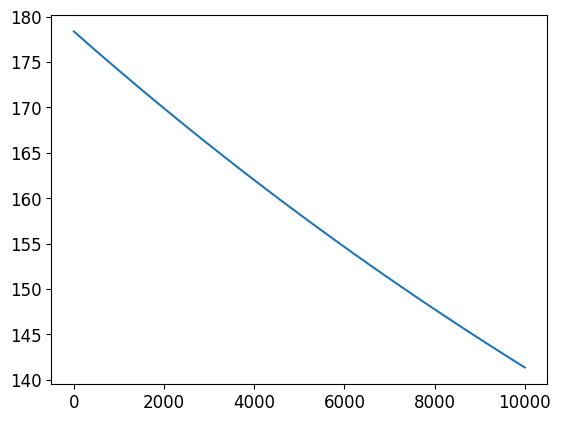

In [323]:
plt.plot(loss_history)

In [324]:
print(g)

[ 0.18846482  0.0146698   0.02709859  0.01993918 -0.00165252  0.00453845
 -0.00397607]


In [318]:
S_lambd = np.logspace(-1, 7.6, 15)

<a name="task-12"></a>

## (1.2) [(index)](#index-task-12)

<a name="task-13"></a>

## (1.3) [(index)](#index-task-13)

<a name="task-14"></a>

## (1.4) [(index)](#index-task-14)

<a name="task-2"></a>

# Task 2: Non-linear regression with Kernel Ridge Regression [(index)](#index-task-2)

<a name="task-21"></a>

## (2.1) [(index)](#index-task-21)

<a name="task-22"></a>

## (2.2) [(index)](#index-task-22)

<a name="task-3"></a>

# Task 3: Classification with the Multi-Layer Perceptron [(index)](#index-task-3)

<a name="task-31"></a>

## (3.1) [(index)](#index-task-31)

<a name="task-32"></a>

## (3.2) [(index)](#index-task-32)